In [1]:
# Import necessary libraries
import pandas as pd # For data manipulation and analysis
import numpy as np  # For numerical operations, especially with arrays
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns # For making statistical graphics based on matplotlib

In [6]:
# Convert the 'target' column into a binary variable
# Original values: 0 = no disease, 1-4 = disease presence
# New values: 0 = no disease, 1 = disease presence

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Display the value counts of the new target variable to verify the conversion
print("Value counts for the 'target' variable after binarization:")
print(df['target'].value_counts())

# Display the first few rows with the updated target column
print("\nFirst 5 rows of the dataset with updated 'target' column:")
print(df.head())

Value counts for the 'target' variable after binarization:
target
0    164
1    139
Name: count, dtype: int64

First 5 rows of the dataset with updated 'target' column:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope  ca  thal  target  
0    3.0   0     6       0  
1    2.0   3     3       1  
2    2.0   2     7       1  
3    3.0   0     3       0  
4    1.0   0     3       0  


In [7]:
# Identify categorical columns that need one-hot encoding.
# These columns are currently numerical but represent categories.
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Convert specified categorical columns to 'category' dtype first.
# This helps pandas' get_dummies function identify them correctly.
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Apply one-hot encoding using pd.get_dummies()
# drop_first=True prevents multicollinearity by dropping one category from each feature.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame to see the changes
print("First 5 rows of the DataFrame after one-hot encoding:")
print(df_encoded.head())

# Display the new shape of the DataFrame to show the increase in columns
print("\nShape of the DataFrame after one-hot encoding:", df_encoded.shape)

First 5 rows of the DataFrame after one-hot encoding:
    age  trestbps   chol  thalach  oldpeak  target  sex_1.0  cp_2.0  cp_3.0  \
0  63.0     145.0  233.0    150.0      2.3       0     True   False   False   
1  67.0     160.0  286.0    108.0      1.5       1     True   False   False   
2  67.0     120.0  229.0    129.0      2.6       1     True   False   False   
3  37.0     130.0  250.0    187.0      3.5       0     True   False    True   
4  41.0     130.0  204.0    172.0      1.4       0    False    True   False   

   cp_4.0  ...  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  slope_3.0  \
0   False  ...        False         True      False      False       True   
1    True  ...        False         True       True       True      False   
2    True  ...        False         True       True       True      False   
3   False  ...        False        False      False      False       True   
4   False  ...        False         True      False      False      False   

    ca_1

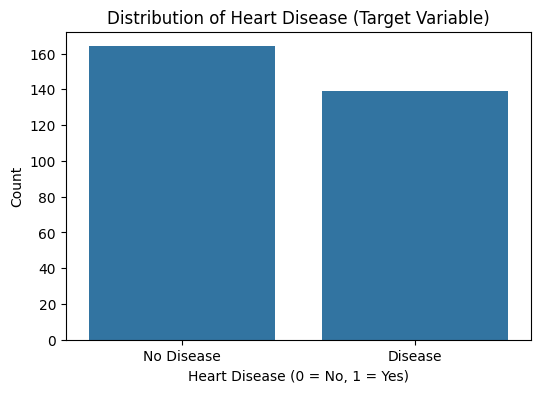

Interpretation: This plot shows the number of patients with and without heart disease in our dataset. A balanced distribution (roughly equal counts) is generally good for training classification models.


In [8]:
# Visualize the distribution of the target variable
# This helps us understand if our dataset is balanced or imbalanced regarding heart disease presence.
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_encoded)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.show()

print("Interpretation: This plot shows the number of patients with and without heart disease in our dataset. A balanced distribution (roughly equal counts) is generally good for training classification models.")

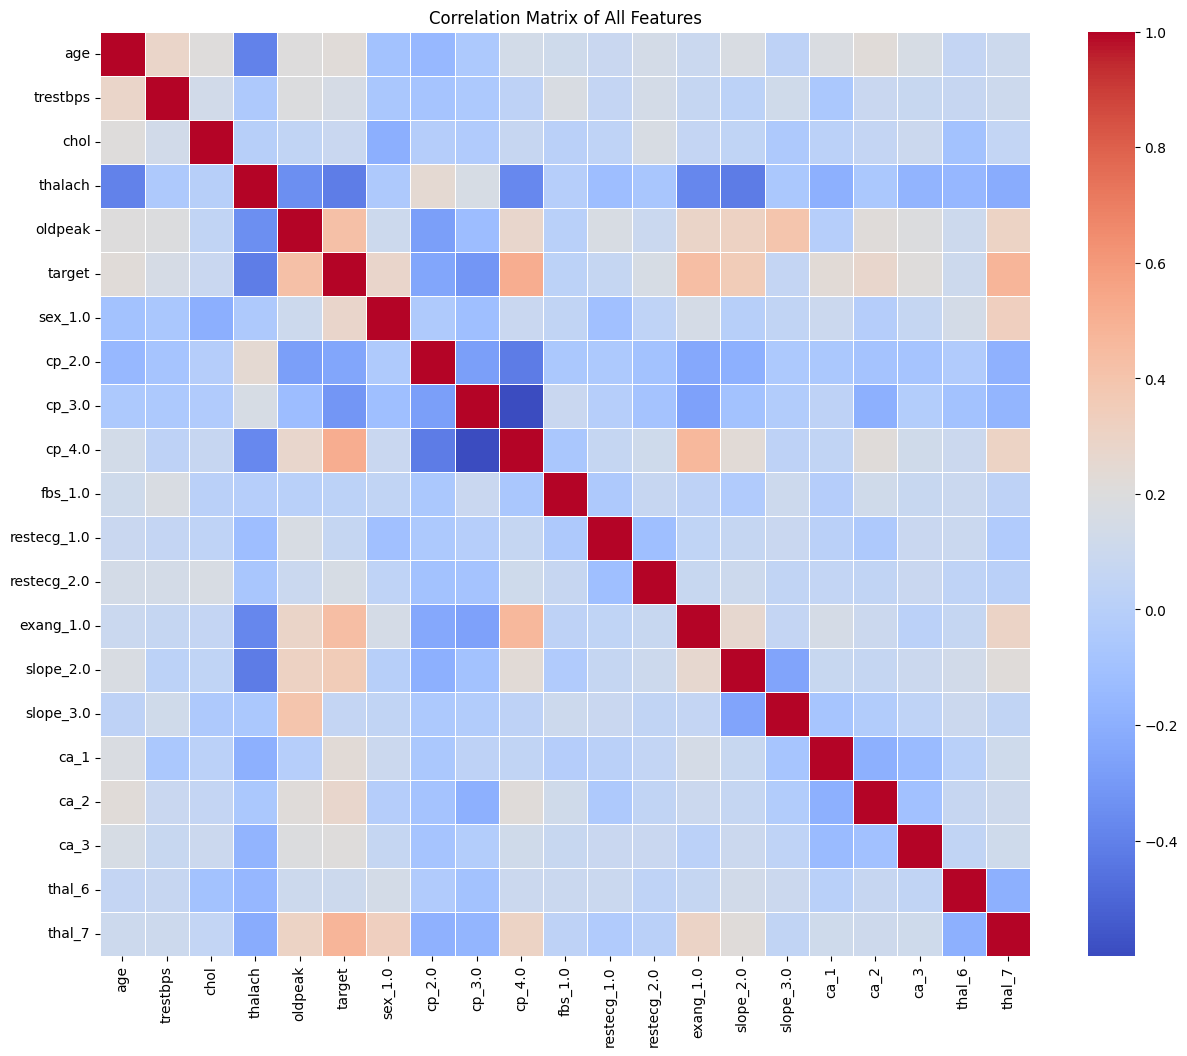


Correlation of features with the Target variable:
target         1.000000
cp_4.0         0.516459
thal_7         0.480582
exang_1.0      0.431894
oldpeak        0.424510
slope_2.0      0.355709
sex_1.0        0.276816
ca_2           0.271334
ca_1           0.228818
age            0.223120
ca_3           0.208734
restecg_2.0    0.160400
trestbps       0.150825
thal_6         0.104864
chol           0.085164
restecg_1.0    0.067605
slope_3.0      0.061710
fbs_1.0        0.025264
cp_2.0        -0.248683
cp_3.0        -0.315141
thalach       -0.417167
Name: target, dtype: float64


In [9]:
# Calculate the correlation matrix for all features
# This helps in understanding the relationships between variables.
correlation_matrix = df_encoded.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

# Display correlations with the target variable explicitly
print("\nCorrelation of features with the Target variable:")
print(correlation_matrix['target'].sort_values(ascending=False))

In [10]:
# Separate features (X) and target (y)
# X will contain all columns except 'target'
# y will contain only the 'target' column
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Display the shapes of X and y to confirm the separation
print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# Display the first few rows of X and y to inspect
print("\nFirst 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

Shape of features (X): (303, 20)
Shape of target (y): (303,)

First 5 rows of features (X):
    age  trestbps   chol  thalach  oldpeak  sex_1.0  cp_2.0  cp_3.0  cp_4.0  \
0  63.0     145.0  233.0    150.0      2.3     True   False   False   False   
1  67.0     160.0  286.0    108.0      1.5     True   False   False    True   
2  67.0     120.0  229.0    129.0      2.6     True   False   False    True   
3  37.0     130.0  250.0    187.0      3.5     True   False    True   False   
4  41.0     130.0  204.0    172.0      1.4    False    True   False   False   

   fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  slope_3.0   ca_1  \
0     True        False         True      False      False       True  False   
1    False        False         True       True       True      False  False   
2    False        False         True       True       True      False  False   
3    False        False        False      False      False       True  False   
4    False        False         T

In [11]:
# Import the train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# test_size=0.20 means 20% of the data will be used for testing
# random_state ensures reproducibility of the split
# stratify=y ensures that the proportion of target classes is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Display the shapes of the resulting sets to confirm the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of target in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of target in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (242, 20)
Shape of X_test: (61, 20)
Shape of y_train: (242,)
Shape of y_test: (61,)

Distribution of target in y_train:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Distribution of target in y_test:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [12]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# These are the columns that were not one-hot encoded and are continuous.
# We need to consider the original columns that remained, minus the 'target' if it was still in df_encoded before separation.
# Since we dropped 'target' from df_encoded to create X, we can use X.columns directly.

# Get the list of numerical features from X_train (before scaling)
# These are columns that were not part of the `categorical_cols` that were one-hot encoded.
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns in both training and testing sets
# Fit the scaler on the training data and transform both training and testing data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Display the first few rows of the scaled training data to verify
print("First 5 rows of X_train after scaling numerical features:")
print(X_train.head())

# Display descriptive statistics of scaled numerical features to confirm mean ~0 and std ~1
print("\nDescriptive statistics of numerical features in X_train after scaling:")
print(X_train[numerical_cols].describe())

First 5 rows of X_train after scaling numerical features:
          age  trestbps      chol   thalach   oldpeak  sex_1.0  cp_2.0  \
180 -0.729485 -0.395692  0.458139  0.708371 -0.445445     True   False   
208  0.050166 -0.054513  0.230598  0.222495 -0.891627     True    True   
167 -0.061212  0.059213  0.723605  0.399178 -0.891627    False    True   
105 -0.061212 -1.305501  1.121803  0.266666 -0.891627     True    True   
297  0.272924  0.514117 -0.167601 -1.190962 -0.713154    False   False   

     cp_3.0  cp_4.0  fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  \
180   False    True    False        False         True      False       True   
208   False   False    False        False        False      False      False   
167   False   False     True        False         True       True      False   
105   False   False    False        False        False      False      False   
297   False    True    False        False        False       True       True   

     slope_3.0  

In [13]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# These are the columns that were not one-hot encoded and are continuous.
# We need to consider the original columns that remained, minus the 'target' if it was still in df_encoded before separation.
# Since we dropped 'target' from df_encoded to create X, we can use X.columns directly.

# Get the list of numerical features from X_train (before scaling)
# These are columns that were not part of the `categorical_cols` that were one-hot encoded.
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns in both training and testing sets
# Fit the scaler on the training data and transform both training and testing data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Display the first few rows of the scaled training data to verify
print("First 5 rows of X_train after scaling numerical features:")
print(X_train.head())

# Display descriptive statistics of scaled numerical features to confirm mean ~0 and std ~1
print("\nDescriptive statistics of numerical features in X_train after scaling:")
print(X_train[numerical_cols].describe())

First 5 rows of X_train after scaling numerical features:
          age  trestbps      chol   thalach   oldpeak  sex_1.0  cp_2.0  \
180 -0.729485 -0.395692  0.458139  0.708371 -0.445445     True   False   
208  0.050166 -0.054513  0.230598  0.222495 -0.891627     True    True   
167 -0.061212  0.059213  0.723605  0.399178 -0.891627    False    True   
105 -0.061212 -1.305501  1.121803  0.266666 -0.891627     True    True   
297  0.272924  0.514117 -0.167601 -1.190962 -0.713154    False   False   

     cp_3.0  cp_4.0  fbs_1.0  restecg_1.0  restecg_2.0  exang_1.0  slope_2.0  \
180   False    True    False        False         True      False       True   
208   False   False    False        False        False      False      False   
167   False   False     True        False         True       True      False   
105   False   False    False        False        False      False      False   
297   False    True    False        False        False       True       True   

     slope_3.0  

Logistic Regression Model Performance:
Accuracy: 0.8689
Precision: 0.8333
Recall: 0.8929
F1-score: 0.8621

Confusion Matrix:
[[28  5]
 [ 3 25]]


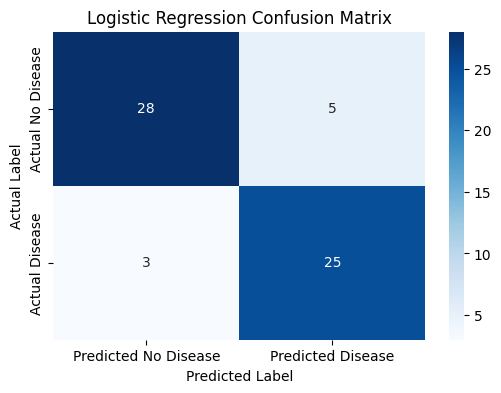

In [16]:
# Import necessary metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Calculate the confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_lr)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [17]:
# Import Support Vector Classifier model
from sklearn.svm import SVC

# Initialize the SVC model
# probability=True is needed to get probability predictions for 'Disease Risk Probability'
# random_state ensures reproducibility
svm_model = SVC(kernel='linear', probability=True, random_state=42)

# Train the model using the scaled training data
print("Training Support Vector Machine (SVM) model...")
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

# Make predictions on the scaled test data
y_pred_svm = svm_model.predict(X_test)

# Make probability predictions on the scaled test data
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("\nFirst 5 SVM predictions on test set:")
print(y_pred_svm[:5])
print("\nFirst 5 SVM probability predictions on test set:")
print(y_prob_svm[:5])

Training Support Vector Machine (SVM) model...
SVM model trained successfully.

First 5 SVM predictions on test set:
[0 1 0 0 0]

First 5 SVM probability predictions on test set:
[0.20200007 0.53954324 0.03268239 0.0505672  0.26476346]


Support Vector Machine (SVM) Model Performance:
Accuracy: 0.8361
Precision: 0.8000
Recall: 0.8571
F1-score: 0.8276

Confusion Matrix:
[[27  6]
 [ 4 24]]


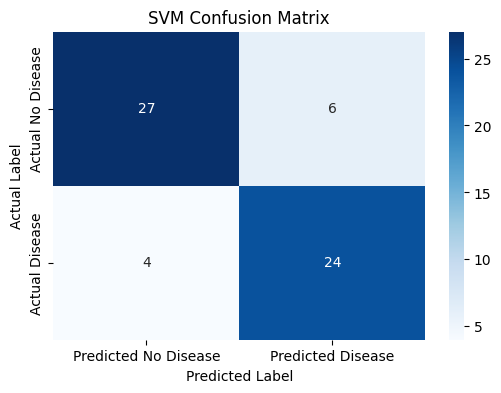


Interpretation: The confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions by the SVM model. These numbers are used to calculate the accuracy, precision, recall, and F1-score.


In [18]:
# Import necessary metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for Support Vector Machine (SVM)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# Calculate the confusion matrix for SVM
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f"Support Vector Machine (SVM) Model Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_svm)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation: The confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions by the SVM model. These numbers are used to calculate the accuracy, precision, recall, and F1-score.")

Support Vector Machine (SVM) Model Performance:
Accuracy: 0.8361
Precision: 0.8000
Recall: 0.8571
F1-score: 0.8276

Confusion Matrix:
[[27  6]
 [ 4 24]]


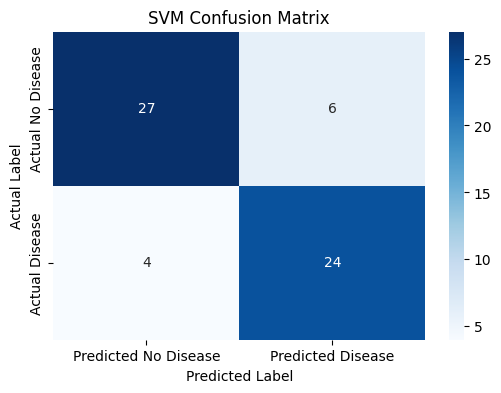


Interpretation: The confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions by the SVM model. These numbers are used to calculate the accuracy, precision, recall, and F1-score.
Training Random Forest Classifier model...
Random Forest Classifier model trained successfully.

Out-of-Bag (OOB) score: 0.7645

First 5 Random Forest predictions on test set:
[0 1 0 0 0]

First 5 Random Forest probability predictions on test set:
[0.39 0.66 0.06 0.07 0.34]


In [20]:
# Import necessary metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for Support Vector Machine (SVM)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# Calculate the confusion matrix for SVM
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f"Support Vector Machine (SVM) Model Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_svm)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation: The confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions by the SVM model. These numbers are used to calculate the accuracy, precision, recall, and F1-score.")

# Import the RandomForestClassifier model
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# n_estimators is the number of trees in the forest
# random_state ensures reproducibility
# OOB score is 'out-of-bag' estimates, which is a form of cross-validation on the training set
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)

# Train the model using the scaled training data
print("Training Random Forest Classifier model...")
rf_model.fit(X_train, y_train)
print("Random Forest Classifier model trained successfully.")

# Make predictions on the scaled test data
y_pred_rf = rf_model.predict(X_test)

# Make probability predictions on the scaled test data
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"\nOut-of-Bag (OOB) score: {rf_model.oob_score_:.4f}")
print("\nFirst 5 Random Forest predictions on test set:")
print(y_pred_rf[:5])
print("\nFirst 5 Random Forest probability predictions on test set:")
print(y_prob_rf[:5])

Training Random Forest Classifier model...
Random Forest Classifier model trained successfully.

Out-of-Bag (OOB) score: 0.7645

First 5 Random Forest predictions on test set:
[0 1 0 0 0]

First 5 Random Forest probability predictions on test set:
[0.39 0.66 0.06 0.07 0.34]
Random Forest Classifier Model Performance:
Accuracy: 0.8689
Precision: 0.8333
Recall: 0.8929
F1-score: 0.8621

Confusion Matrix:
[[28  5]
 [ 3 25]]


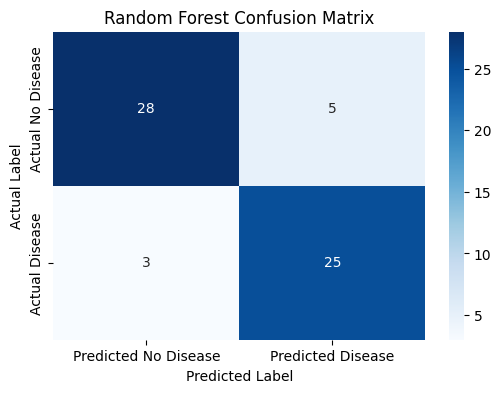


Interpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the Random Forest model's predictions. These values are crucial for understanding the model's strengths and weaknesses beyond just accuracy.


In [22]:
# Import the RandomForestClassifier model
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# n_estimators is the number of trees in the forest
# random_state ensures reproducibility
# OOB score is 'out-of-bag' estimates, which is a form of cross-validation on the training set
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)

# Train the model using the scaled training data
print("Training Random Forest Classifier model...")
rf_model.fit(X_train, y_train)
print("Random Forest Classifier model trained successfully.")

# Make predictions on the scaled test data
y_pred_rf = rf_model.predict(X_test)

# Make probability predictions on the scaled test data
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"\nOut-of-Bag (OOB) score: {rf_model.oob_score_:.4f}")
print("\nFirst 5 Random Forest predictions on test set:")
print(y_pred_rf[:5])
print("\nFirst 5 Random Forest probability predictions on test set:")
print(y_prob_rf[:5])

# Import necessary metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for Random Forest Classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Calculate the confusion matrix for Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_rf)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the Random Forest model's predictions. These values are crucial for understanding the model's strengths and weaknesses beyond just accuracy.")

Random Forest Classifier Model Performance:
Accuracy: 0.8689
Precision: 0.8333
Recall: 0.8929
F1-score: 0.8621

Confusion Matrix:
[[28  5]
 [ 3 25]]


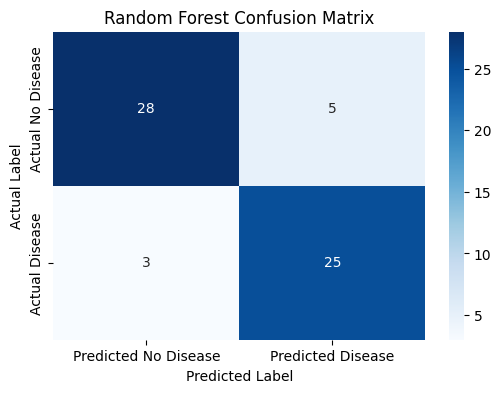


Interpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the Random Forest model's predictions. These values are crucial for understanding the model's strengths and weaknesses beyond just accuracy.
Training XGBoost Classifier model...
XGBoost Classifier model trained successfully.

First 5 XGBoost predictions on test set:
[1 0 0 0 0]

First 5 XGBoost probability predictions on test set:
[0.9845804  0.31335837 0.00193469 0.01019417 0.2692085 ]


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [07:26:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [24]:
# Import necessary metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for Random Forest Classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Calculate the confusion matrix for Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_rf)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the Random Forest model's predictions. These values are crucial for understanding the model's strengths and weaknesses beyond just accuracy.")

# Import the XGBoost Classifier model
import xgboost as xgb

# Initialize the XGBoost Classifier model
# use_label_encoder=False and eval_metric='logloss' are set to suppress warnings
# random_state ensures reproducibility
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Train the model using the scaled training data
print("Training XGBoost Classifier model...")
xgb_model.fit(X_train, y_train)
print("XGBoost Classifier model trained successfully.")

# Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test)

# Make probability predictions on the scaled test data
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nFirst 5 XGBoost predictions on test set:")
print(y_pred_xgb[:5])
print("\nFirst 5 XGBoost probability predictions on test set:")
print(y_prob_xgb[:5])

Training XGBoost Classifier model...
XGBoost Classifier model trained successfully.

First 5 XGBoost predictions on test set:
[1 0 0 0 0]

First 5 XGBoost probability predictions on test set:
[0.9845804  0.31335837 0.00193469 0.01019417 0.2692085 ]
XGBoost Classifier Model Performance:
Accuracy: 0.8525
Precision: 0.8276
Recall: 0.8571
F1-score: 0.8421

Confusion Matrix:
[[28  5]
 [ 4 24]]


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [07:27:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


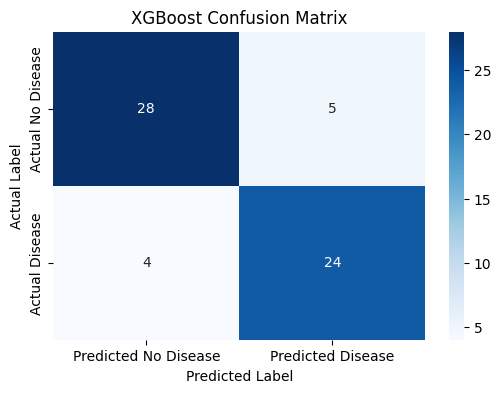


Interpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the XGBoost model's predictions. These values are crucial for understanding the model's strengths and weaknesses.


In [26]:
# Import the XGBoost Classifier model
import xgboost as xgb

# Initialize the XGBoost Classifier model
# use_label_encoder=False and eval_metric='logloss' are set to suppress warnings
# random_state ensures reproducibility
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Train the model using the scaled training data
print("Training XGBoost Classifier model...")
xgb_model.fit(X_train, y_train)
print("XGBoost Classifier model trained successfully.")

# Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test)

# Make probability predictions on the scaled test data
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nFirst 5 XGBoost predictions on test set:")
print(y_pred_xgb[:5])
print("\nFirst 5 XGBoost probability predictions on test set:")
print(y_prob_xgb[:5])

# Import necessary metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for XGBoost Classifier
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Calculate the confusion matrix for XGBoost
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-score: {f1_xgb:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_xgb)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the XGBoost model's predictions. These values are crucial for understanding the model's strengths and weaknesses.")

XGBoost Classifier Model Performance:
Accuracy: 0.8525
Precision: 0.8276
Recall: 0.8571
F1-score: 0.8421

Confusion Matrix:
[[28  5]
 [ 4 24]]


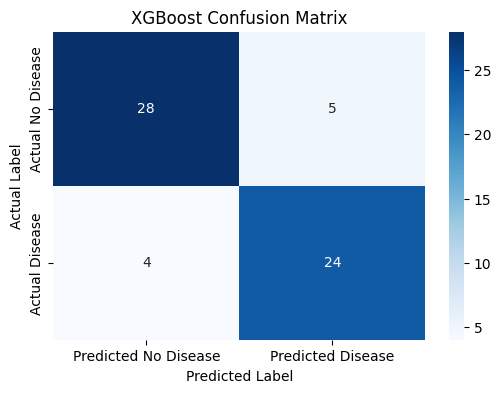


Interpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the XGBoost model's predictions. These values are crucial for understanding the model's strengths and weaknesses.

--- Model Performance Comparison ---
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.8689     0.8333  0.8929    0.8621
2        Random Forest    0.8689     0.8333  0.8929    0.8621
3              XGBoost    0.8525     0.8276  0.8571    0.8421
1                  SVM    0.8361     0.8000  0.8571    0.8276

Interpretation: This table summarizes the key performance metrics for each trained model. By comparing these values, we can assess which model offers the best balance of accuracy, precision, recall, and F1-score for our heart disease prediction task.


In [28]:
# Import necessary metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for XGBoost Classifier
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Calculate the confusion matrix for XGBoost
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-score: {f1_xgb:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_xgb)

# Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation: This confusion matrix displays the true positives, true negatives, false positives, and false negatives from the XGBoost model's predictions. These values are crucial for understanding the model's strengths and weaknesses.")

# Create a dictionary to store the performance metrics of all models
model_performance = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_svm, accuracy_rf, accuracy_xgb],
    'Precision': [precision_lr, precision_svm, precision_rf, precision_xgb],
    'Recall': [recall_lr, recall_svm, recall_rf, recall_xgb],
    'F1-score': [f1_lr, f1_svm, f1_rf, f1_xgb]
}

# Convert the dictionary to a Pandas DataFrame for easy viewing and comparison
performance_df = pd.DataFrame(model_performance)

# Sort the DataFrame by F1-score (or Accuracy) in descending order to see the best performing models first
performance_df_sorted = performance_df.sort_values(by='F1-score', ascending=False)

print("\n--- Model Performance Comparison ---")
print(performance_df_sorted.round(4))

print("\nInterpretation: This table summarizes the key performance metrics for each trained model. By comparing these values, we can assess which model offers the best balance of accuracy, precision, recall, and F1-score for our heart disease prediction task.")

In [30]:
# Create a dictionary to store the performance metrics of all models
model_performance = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_svm, accuracy_rf, accuracy_xgb],
    'Precision': [precision_lr, precision_svm, precision_rf, precision_xgb],
    'Recall': [recall_lr, recall_svm, recall_rf, recall_xgb],
    'F1-score': [f1_lr, f1_svm, f1_rf, f1_xgb]
}

# Convert the dictionary to a Pandas DataFrame for easy viewing and comparison
performance_df = pd.DataFrame(model_performance)

# Sort the DataFrame by F1-score (or Accuracy) in descending order to see the best performing models first
performance_df_sorted = performance_df.sort_values(by='F1-score', ascending=False)

print("\n--- Model Performance Comparison ---")
print(performance_df_sorted.round(4))

print("\nInterpretation: This table summarizes the key performance metrics for each trained model. By comparing these values, we can assess which model offers the best balance of accuracy, precision, recall, and F1-score for our heart disease prediction task.")

# Displaying 'Disease Risk Probability' for a few test samples for each model

# Create a DataFrame to hold actual values, predicted classes, and probabilities
probability_df = pd.DataFrame({
    'Actual': y_test,
    'LR_Predicted': y_pred_lr,
    'LR_Probability_Disease': y_prob_lr,
    'SVM_Predicted': y_pred_svm,
    'SVM_Probability_Disease': y_prob_svm,
    'RF_Predicted': y_pred_rf,
    'RF_Probability_Disease': y_prob_rf,
    'XGB_Predicted': y_pred_xgb,
    'XGB_Probability_Disease': y_prob_xgb
}, index=X_test.index)

print("\n--- Disease Risk Probability for Sample Test Cases ---")
print("Showing actual disease status, predicted status, and probability of disease for a few patients.")

# Display the first 10 entries of this DataFrame for review
print(probability_df.head(10).round(4))

print("\nInterpretation: This table shows for a selection of test patients: the 'Actual' heart disease status (0=No, 1=Yes), each model's 'Predicted' status, and the 'Probability_Disease' assigned by each model. A higher probability indicates greater confidence in predicting heart disease.")


--- Model Performance Comparison ---
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.8689     0.8333  0.8929    0.8621
2        Random Forest    0.8689     0.8333  0.8929    0.8621
3              XGBoost    0.8525     0.8276  0.8571    0.8421
1                  SVM    0.8361     0.8000  0.8571    0.8276

Interpretation: This table summarizes the key performance metrics for each trained model. By comparing these values, we can assess which model offers the best balance of accuracy, precision, recall, and F1-score for our heart disease prediction task.

--- Disease Risk Probability for Sample Test Cases ---
Showing actual disease status, predicted status, and probability of disease for a few patients.
     Actual  LR_Predicted  LR_Probability_Disease  SVM_Predicted  \
219       0             0                  0.2506              0   
271       0             1                  0.6459              1   
89        0             0                  0

In [31]:
# Displaying 'Disease Risk Probability' for a few test samples for each model

# Create a DataFrame to hold actual values, predicted classes, and probabilities
probability_df = pd.DataFrame({
    'Actual': y_test,
    'LR_Predicted': y_pred_lr,
    'LR_Probability_Disease': y_prob_lr,
    'SVM_Predicted': y_pred_svm,
    'SVM_Probability_Disease': y_prob_svm,
    'RF_Predicted': y_pred_rf,
    'RF_Probability_Disease': y_prob_rf,
    'XGB_Predicted': y_pred_xgb,
    'XGB_Probability_Disease': y_prob_xgb
}, index=X_test.index)

print("--- Disease Risk Probability for Sample Test Cases ---")
print("Showing actual disease status, predicted status, and probability of disease for a few patients.")

# Display the first 10 entries of this DataFrame for review
print(probability_df.head(10).round(4))

print("\nInterpretation: This table shows for a selection of test patients: the 'Actual' heart disease status (0=No, 1=Yes), each model's 'Predicted' status, and the 'Probability_Disease' assigned by each model. A higher probability indicates greater confidence in predicting heart disease.")

--- Disease Risk Probability for Sample Test Cases ---
Showing actual disease status, predicted status, and probability of disease for a few patients.
     Actual  LR_Predicted  LR_Probability_Disease  SVM_Predicted  \
219       0             0                  0.2506              0   
271       0             1                  0.6459              1   
89        0             0                  0.0320              0   
101       0             0                  0.0508              0   
67        0             0                  0.3446              0   
244       0             0                  0.0312              0   
185       0             0                  0.0850              0   
233       0             0                  0.3670              0   
168       1             1                  0.7083              1   
197       0             0                  0.3531              0   

     SVM_Probability_Disease  RF_Predicted  RF_Probability_Disease  \
219                   0.2020  

## Explainable Prediction using Feature Importance

Understanding which features a model considers most important can provide valuable insights into the underlying patterns in the data and increase trust in the model's predictions. Here, we will extract and visualize feature importances for tree-based models like Random Forest and XGBoost.

--- Random Forest Feature Importances ---
thalach        0.125064
thal_7         0.114404
oldpeak        0.107586
cp_4.0         0.093219
age            0.090376
chol           0.085231
trestbps       0.080461
exang_1.0      0.057065
sex_1.0        0.045745
ca_1           0.038692
slope_2.0      0.037728
cp_3.0         0.024458
restecg_2.0    0.023858
ca_2           0.018628
cp_2.0         0.017452
ca_3           0.014103
fbs_1.0        0.012596
thal_6         0.008997
slope_3.0      0.004018
restecg_1.0    0.000319
dtype: float64


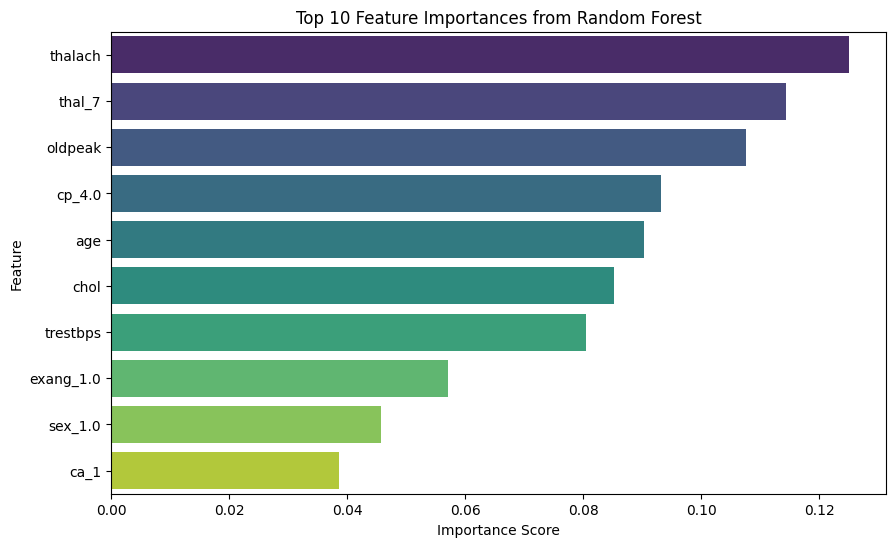


Interpretation: This chart highlights the top 10 features that the Random Forest model considered most important for predicting heart disease. Features with higher importance scores have a greater impact on the model's decisions.

--- XGBoost Feature Importances ---
thal_7         0.263474
cp_4.0         0.142556
ca_1           0.090938
slope_2.0      0.064039
cp_2.0         0.062021
sex_1.0        0.055777
thalach        0.042228
ca_2           0.038470
age            0.037482
trestbps       0.035359
oldpeak        0.033552
exang_1.0      0.030114
restecg_2.0    0.029875
chol           0.029156
cp_3.0         0.028702
fbs_1.0        0.016258
restecg_1.0    0.000000
slope_3.0      0.000000
ca_3           0.000000
thal_6         0.000000
dtype: float32


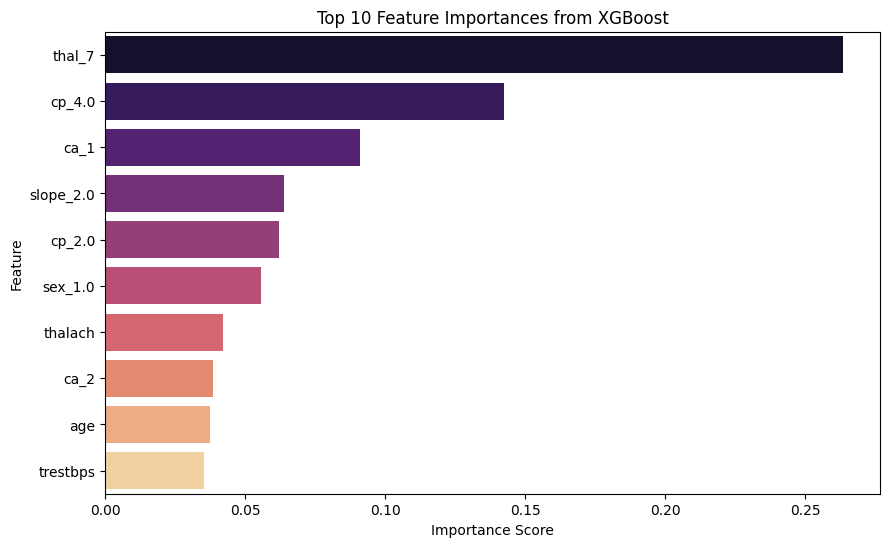


Interpretation: Similarly, this chart shows the top 10 features that the XGBoost model found most influential. Comparing these with the Random Forest importances can reveal consistent patterns or highlight differences in how these models weigh different factors.


In [33]:
# 1. Feature Importance for Random Forest Model
print("--- Random Forest Feature Importances ---")
feature_importances_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_importances_rf)

# Visualize Random Forest Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_rf.head(10).values, y=feature_importances_rf.head(10).index, palette='viridis', hue=feature_importances_rf.head(10).index, legend=False)
plt.title('Top 10 Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("\nInterpretation: This chart highlights the top 10 features that the Random Forest model considered most important for predicting heart disease. Features with higher importance scores have a greater impact on the model's decisions.")

# 2. Feature Importance for XGBoost Model
print("\n--- XGBoost Feature Importances ---")
feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_importances_xgb)

# Visualize XGBoost Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_xgb.head(10).values, y=feature_importances_xgb.head(10).index, palette='magma', hue=feature_importances_xgb.head(10).index, legend=False)
plt.title('Top 10 Feature Importances from XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("\nInterpretation: Similarly, this chart shows the top 10 features that the XGBoost model found most influential. Comparing these with the Random Forest importances can reveal consistent patterns or highlight differences in how these models weigh different factors.")

In [15]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# random_state ensures reproducibility of results
log_reg = LogisticRegression(random_state=42)

# Train the model using the scaled training data
print("Training Logistic Regression model...")
log_reg.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

# Make predictions on the scaled test data
y_pred_lr = log_reg.predict(X_test)

# Make probability predictions on the scaled test data (for Disease Risk Probability)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print("\nFirst 5 Logistic Regression predictions on test set:")
print(y_pred_lr[:5])
print("\nFirst 5 Logistic Regression probability predictions on test set:")
print(y_prob_lr[:5])

Training Logistic Regression model...
Logistic Regression model trained successfully.

First 5 Logistic Regression predictions on test set:
[0 1 0 0 0]

First 5 Logistic Regression probability predictions on test set:
[0.25058806 0.64587427 0.03197762 0.05082484 0.34461465]


In [4]:
# Check for duplicate rows in the DataFrame
# .duplicated().sum() counts the number of duplicate rows (excluding the first occurrence)
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicate rows if any exist
# .drop_duplicates(inplace=True) modifies the DataFrame in place
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f"\nNumber of rows after removing duplicates: {final_rows} (removed {initial_rows - final_rows} duplicates)")

# Display the shape of the DataFrame after cleaning to confirm changes
print("\nShape of the DataFrame after cleaning:", df.shape)

Number of duplicate rows: 0

Number of rows after removing duplicates: 303 (removed 0 duplicates)

Shape of the DataFrame after cleaning: (303, 14)


In [2]:
# Define column names as per the UCI Heart Disease Dataset documentation
# This helps in understanding what each column represents
column_names = [
    'age',          # Age in years
    'sex',          # Sex (1 = male; 0 = female)
    'cp',           # Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)
    'trestbps',     # Resting blood pressure (in mm Hg on admission to the hospital)
    'chol',         # Serum cholestoral in mg/dl
    'fbs',          # Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
    'restecg',      # Resting electrocardiographic results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)
    'thalach',      # Maximum heart rate achieved
    'exang',        # Exercise induced angina (1 = yes; 0 = no)
    'oldpeak',      # ST depression induced by exercise relative to rest
    'slope',        # The slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)
    'ca',           # Number of major vessels (0-3) colored by flourosopy
    'thal',         # Thallium stress test result (3: normal, 6: fixed defect, 7: reversible defect)
    'target'        # Diagnosis of heart disease (0: no disease, 1-4: disease presence - we'll convert to 0/1)
]

# Load the dataset
# The dataset typically uses '?' for missing values, so we specify this during loading
df = pd.read_csv('/content/processed.cleveland.data', names=column_names, na_values='?')

# Display the first 5 rows of the DataFrame to get a glimpse of the data
print("First 5 rows of the dataset:")
print(df.head())

# Display basic information about the DataFrame, including data types and non-null values
print("\nInformation about the dataset:")
df.info()

First 5 rows of the dataset:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    floa

In [5]:
# Check for missing values in the DataFrame
# .isnull() returns a boolean DataFrame indicating missing values
# .sum() counts the number of True values (missing values) per column
print("Missing values per column:")
print(df.isnull().sum())

# Handle missing values by imputation (filling them)
# For numerical columns, the median is often a robust choice to avoid being skewed by outliers.
# 'ca' and 'thal' are categorical in nature (number of vessels, thallium test result) but are loaded as float.
# We will convert them to integers after filling NaNs.

# Fill missing 'ca' values with the median of the 'ca' column
# Avoid inplace=True to prevent FutureWarning
df['ca'] = df['ca'].fillna(df['ca'].median())
# Fill missing 'thal' values with the median of the 'thal' column
# Avoid inplace=True to prevent FutureWarning
df['thal'] = df['thal'].fillna(df['thal'].median())

# Convert 'ca' and 'thal' to integer type after imputation
# This makes sense as they represent categories/counts.
df['ca'] = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)

# Verify that there are no more missing values
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Display the data types after conversion
print("\nData types after converting 'ca' and 'thal' to int:")
print(df.dtypes)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types after converting 'ca' and 'thal' to int:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca            int64
thal          int64
target        int64
dtype: object
